# Przygotowanie danych

In [1]:
import pandas as pd
import numpy as np
import os
import glob

print("="*80)
print(">>> INICJALIZACJA DANYCH: STRATYFIKOWANE ŁADOWANIE <<<")
print("="*80)

# Wzorce plików i parametry
ALL_FILES_PATTERN = "../dane/treningowe/*_netflow-extended.csv" 
SAMPLE_SIZE_PER_FILE = 15000 
RANDOM_SEED = 42

def load_stratified_data(file_pattern, sample_size=10000):
    files = glob.glob(file_pattern)
    dfs = []
    
    print(f"[*] Znaleziono plików: {len(files)}. Rozpoczynam pobieranie próbek...")
    
    for path in files:
        try:
            df_temp = pd.read_csv(path, on_bad_lines="skip", low_memory=False)
            
            # Losowanie (Stratyfikacja)
            if len(df_temp) > sample_size:
                df_sampled = df_temp.sample(n=sample_size, random_state=RANDOM_SEED)
            else:
                df_sampled = df_temp
                
            # Zapisanie źródła i dodanie do listy
            filename = os.path.basename(path)
            df_sampled['original_file'] = filename
            dfs.append(df_sampled)
            print(f"  + {filename}: pobrano {len(df_sampled)} wierszy (z {len(df_temp)})")
            
        except Exception as e:
            print(f"  [ERR] {path}: {e}")
            
    if not dfs: 
        print("[!] Nie znaleziono danych pasujących do wzorca.")
        return pd.DataFrame()
    
    final_df = pd.concat(dfs, ignore_index=True)
    final_df.dropna(axis=1, how='all', inplace=True)
    
    if 'StartTime' in final_df.columns:
        final_df.sort_values(by='StartTime', inplace=True)
        
    return final_df

# 1. Zbiór Treningowy
df_train = load_stratified_data("../dane/treningowe/*geo-1*.csv", sample_size=20000)
print(f"\n[+] Zbiór treningowy gotowy: {df_train.shape}")

# 2. Zbiór Testowy 
df_test = load_stratified_data("../dane/testowe/*geo-1*.csv", sample_size=20000)
print(f"[+] Zbiór testowy gotowy: {df_test.shape}")

# Ujednolicenie kolumn
common_cols = df_train.columns.intersection(df_test.columns)
df_train = df_train[common_cols].copy()
df_test = df_test[common_cols].copy()

>>> INICJALIZACJA DANYCH: STRATYFIKOWANE ŁADOWANIE <<<
[*] Znaleziono plików: 7. Rozpoczynam pobieranie próbek...
  + 2021-04-26_honeypot-cloud-digitalocean-geo-1_netflow-extended.csv: pobrano 10840 wierszy (z 10840)
  + 2021-04-27_honeypot-cloud-digitalocean-geo-1_netflow-extended.csv: pobrano 10262 wierszy (z 10262)
  + 2021-04-28_honeypot-cloud-digitalocean-geo-1_netflow-extended.csv: pobrano 10948 wierszy (z 10948)
  + 2021-04-29_honeypot-cloud-digitalocean-geo-1_netflow-extended.csv: pobrano 10102 wierszy (z 10102)
  + 2021-04-30_honeypot-cloud-digitalocean-geo-1_netflow-extended.csv: pobrano 7765 wierszy (z 7765)
  + 2021-05-01_honeypot-cloud-digitalocean-geo-1_netflow-extended.csv: pobrano 7389 wierszy (z 7389)
  + 2021-05-02_honeypot-cloud-digitalocean-geo-1_netflow-extended.csv: pobrano 8459 wierszy (z 8459)

[+] Zbiór treningowy gotowy: (65765, 95)
[*] Znaleziono plików: 1. Rozpoczynam pobieranie próbek...
  + 2021-05-20_honeypot-cloud-digitalocean-geo-1_netflow-extended.csv:

# Feature Engineering

In [2]:
import umap.umap_ as umap 
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# ==========================================
# KONFIGURACJA CECH
# ==========================================
NUM_COLS = [
    'Dur', 'Rate', 'SrcRate', 'DstRate', 'TotPkts', 'SrcPkts', 'DstPkts',
    'TotBytes', 'SrcBytes', 'DstBytes', 'Load', 'SrcLoad', 'DstLoad',
    'pLoss', 'SrcJitter', 'DstJitter', 'Bytes_per_Pkt', 'Pkts_Ratio', 'Pkts_Freq'
]
BIN_COLS = ['argus_src_loss', 'argus_dst_loss', 'argus_encap', 'argus_mismatch']

# ==========================================
# FUNKCJE PRZETWARZAJĄCE
# ==========================================
def clean_and_engineer(df, valid_states=None, valid_protos=None):
    df = df.copy()
    
    for c in ['Sport', 'Dport', 'TotBytes', 'TotPkts', 'SrcPkts', 'DstPkts', 'Dur']:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)
    
    df['Bytes_per_Pkt'] = df['TotBytes'] / (df['TotPkts'] + 1e-6)
    df['Pkts_Ratio'] = df['SrcPkts'] / (df['DstPkts'] + 1e-6)
    df['Pkts_Freq'] = df['TotPkts'] / (df['Dur'] + 1e-6)
    
    if 'Flgs' in df.columns:
        flgs = df['Flgs'].astype(str)
        df['argus_src_loss'] = flgs.apply(lambda x: 1 if 's' in x else 0)
        df['argus_dst_loss'] = flgs.apply(lambda x: 1 if 'd' in x else 0)
        df['argus_encap']    = flgs.apply(lambda x: 1 if 'e' in x else 0)
        df['argus_mismatch'] = flgs.apply(lambda x: 1 if '*' in x else 0)
    else:
        for c in BIN_COLS: 
            if c not in df.columns: df[c] = 0

    target_ports = [
        21, 22, 23, 3389, 5900, 80, 443, 8080, 8081, 8888, 3128, 1080,
        25, 53, 110, 143, 1433, 3306, 5432, 6379, 27017,
        445, 139, 2323, 5060, 5061, 500, 4500, 123, 1900
    ]
    for p in target_ports:
        df[f'is_dport_{p}'] = (df['Dport'] == p).astype(int)

    if 'State' in df.columns:
        df['State'] = df['State'].astype(str)
        if valid_states is not None:
            df.loc[~df['State'].isin(valid_states), 'State'] = 'OTHER'
            
    if 'Proto' in df.columns:
        df['Proto'] = df['Proto'].astype(str).str.lower()
        if valid_protos is not None:
            df.loc[~df['Proto'].isin(valid_protos), 'Proto'] = 'OTHER'

    return df

def apply_umap_reduction(X, n_components=10):
    print(f"   -> Uruchamianie UMAP (redukcja do {n_components} wymiarów)...")
    if np.isnan(X).any():
        X = np.nan_to_num(X)

    reducer = umap.UMAP(
        n_components=n_components, n_neighbors=15, min_dist=0.0,
        metric='euclidean', n_jobs=1, init='random', random_state=42
    )
    return reducer.fit_transform(X)

def full_preprocessing_pipeline(df_train, df_test):
    print("\n[*] Inżynieria Cech i Czyszczenie...")
    top_states = df_train['State'].astype(str).value_counts().nlargest(20).index.tolist()
    top_protos = df_train['Proto'].astype(str).str.lower().value_counts().nlargest(10).index.tolist()
    
    df_train_eng = clean_and_engineer(df_train, top_states, top_protos)
    df_test_eng  = clean_and_engineer(df_test, top_states, top_protos)
    
    current_bin_cols = [c for c in df_train_eng.columns if c.startswith('is_dport_') or c in BIN_COLS]
    valid_num = [c for c in NUM_COLS if c in df_train_eng.columns]
    
    for col in valid_num:
        df_train_eng[col] = np.log1p(pd.to_numeric(df_train_eng[col], errors='coerce').fillna(0).clip(lower=0))
        df_test_eng[col]  = np.log1p(pd.to_numeric(df_test_eng[col], errors='coerce').fillna(0).clip(lower=0))

    print(f"   -> Cechy numeryczne: {len(valid_num)} | Binarne: {len(current_bin_cols)}")
    print("[*] Skalowanie i Kodowanie (ColumnTransformer)...")
    
    transformer = ColumnTransformer(
        transformers=[
            ('num', RobustScaler(), valid_num),
            ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['State', 'Proto']),
            ('bin', 'passthrough', current_bin_cols)
        ], remainder='drop'
    )
    
    X_train_enc = transformer.fit_transform(df_train_eng)
    X_test_enc  = transformer.transform(df_test_eng)
    return X_train_enc, X_test_enc

# ==========================================
# WYKONANIE
# ==========================================
X_train_matrix, X_test_matrix = full_preprocessing_pipeline(df_train, df_test)
print(f"[+] Wymiary po Preprocessingu: {X_train_matrix.shape}")

X_train_umap = apply_umap_reduction(X_train_matrix, n_components=10)
print(f"[+] Wymiary gotowe dla modelu: {X_train_umap.shape}")


[*] Inżynieria Cech i Czyszczenie...
   -> Cechy numeryczne: 19 | Binarne: 34
[*] Skalowanie i Kodowanie (ColumnTransformer)...
[+] Wymiary po Preprocessingu: (65765, 79)
   -> Uruchamianie UMAP (redukcja do 10 wymiarów)...
[+] Wymiary gotowe dla modelu: (65765, 10)


# Sprawdzenie wartości K (Elbow Method & Silhoutte Score)

>>> DOBÓR OPTYMALNEJ LICZBY KLASTRÓW K-MEANS <<<
[*] Przeszukiwanie przedziału k=2 do 30...
  -> k=2  | Silhouette=0.0694 | Inertia=9028597
  -> k=5  | Silhouette=0.0600 | Inertia=7989810
  -> k=10 | Silhouette=0.0646 | Inertia=6979325
  -> k=15 | Silhouette=0.1064 | Inertia=6372144
  -> k=20 | Silhouette=0.0224 | Inertia=5981765
  -> k=25 | Silhouette=0.0369 | Inertia=5631970
  -> k=30 | Silhouette=0.0508 | Inertia=5377802

[SUKCES] Zapisano wykres do pliku: ../wykresy\01_kmeans_elbow_silhouette.png


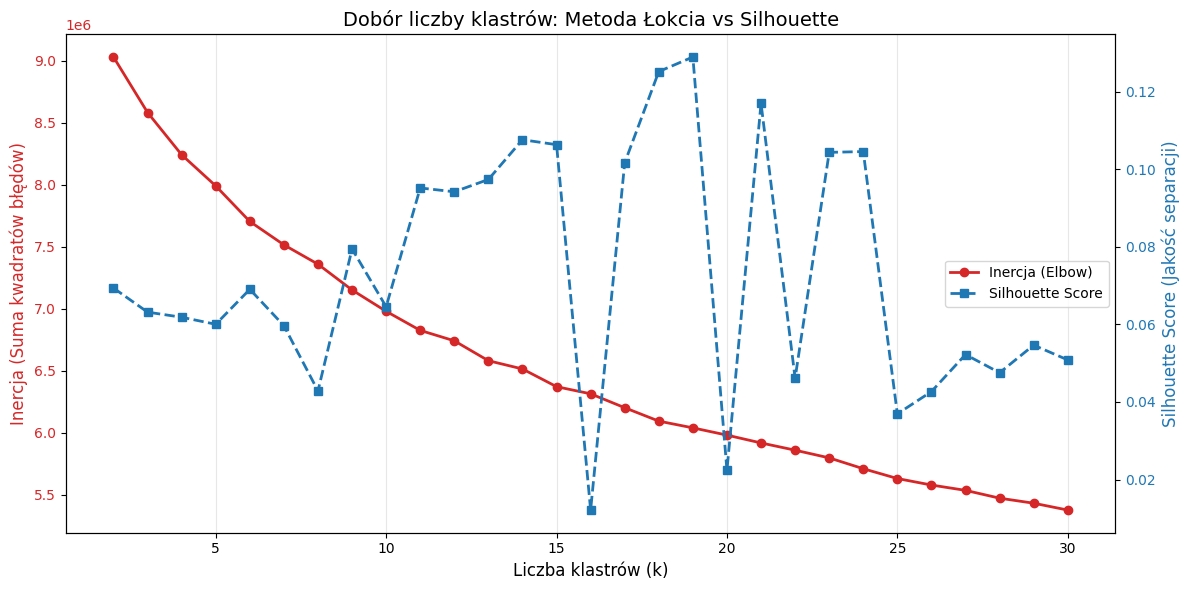

In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np
import os

print("="*80)
print(">>> DOBÓR OPTYMALNEJ LICZBY KLASTRÓW K-MEANS <<<")
print("="*80)

K_RANGE = range(2, 31) 
inertia = []
sil_scores = []
SAMPLE_SIZE = 15000

if len(X_train_umap) > SAMPLE_SIZE:
    rng = np.random.RandomState(42)
    idx = rng.choice(len(X_train_umap), SAMPLE_SIZE, replace=False)
    X_sample_sil = X_train_umap[idx]
else:
    X_sample_sil = X_train_umap

X_full_inertia = X_train_umap

print(f"[*] Przeszukiwanie przedziału k={K_RANGE.start} do {K_RANGE.stop-1}...")

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_full_inertia)
    
    inertia.append(km.inertia_)
    labels_sample = km.predict(X_sample_sil)
    score = silhouette_score(X_sample_sil, labels_sample)
    sil_scores.append(score)
    
    if k % 5 == 0 or k == K_RANGE.start:
        print(f"  -> k={k:<2} | Silhouette={score:.4f} | Inertia={km.inertia_:.0f}")

# Wizualizacja (Dual Axis)
fig, ax1 = plt.subplots(figsize=(12, 6))

color_inertia = 'tab:red'
ax1.set_xlabel('Liczba klastrów (k)', fontsize=12)
ax1.set_ylabel('Inercja (Suma kwadratów błędów)', color=color_inertia, fontsize=12)
line1 = ax1.plot(K_RANGE, inertia, marker='o', linestyle='-', color=color_inertia, label='Inercja (Elbow)', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color_inertia)
ax1.grid(True, axis='x', alpha=0.3)

ax2 = ax1.twinx()  
color_sil = 'tab:blue'
ax2.set_ylabel('Silhouette Score (Jakość separacji)', color=color_sil, fontsize=12)
line2 = ax2.plot(K_RANGE, sil_scores, marker='s', linestyle='--', color=color_sil, label='Silhouette Score', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color_sil)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right')

plt.title('Dobór liczby klastrów: Metoda Łokcia vs Silhouette', fontsize=14)
plt.tight_layout()

# ==========================================
# ZAPISYWANIE WYKRESU DO FOLDERU
# ==========================================
output_dir = '../wykresy'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

file_path = os.path.join(output_dir, '01_kmeans_elbow_silhouette.png')
plt.savefig(file_path, dpi=300, bbox_inches='tight')
print(f"\n[SUKCES] Zapisano wykres do pliku: {file_path}")

plt.show()

# KMeans

>>> TRENOWANIE K-MEANS (K=19) <<<

[*] ROZKŁAD KLASTRÓW:
0      1865
1      3056
2      2271
3      2235
4      1667
5      2058
6      3268
7      2231
8      2805
9      2444
10     3555
11     2726
12     2905
13     2114
14     2038
15     2128
16     2051
17    21979
18     2369
Name: count, dtype: int64
------------------------------
[+] Davies-Bouldin Index: 1.9673 (Im mniej, tym lepiej)
[+] Silhouette Score:     0.1270 (Na próbce 10k)

[*] Generowanie rzutu 2D dla wizualizacji...
[SUKCES] Wykres zapisany jako: ../wykresy\kmeans_baseline_clusters.png


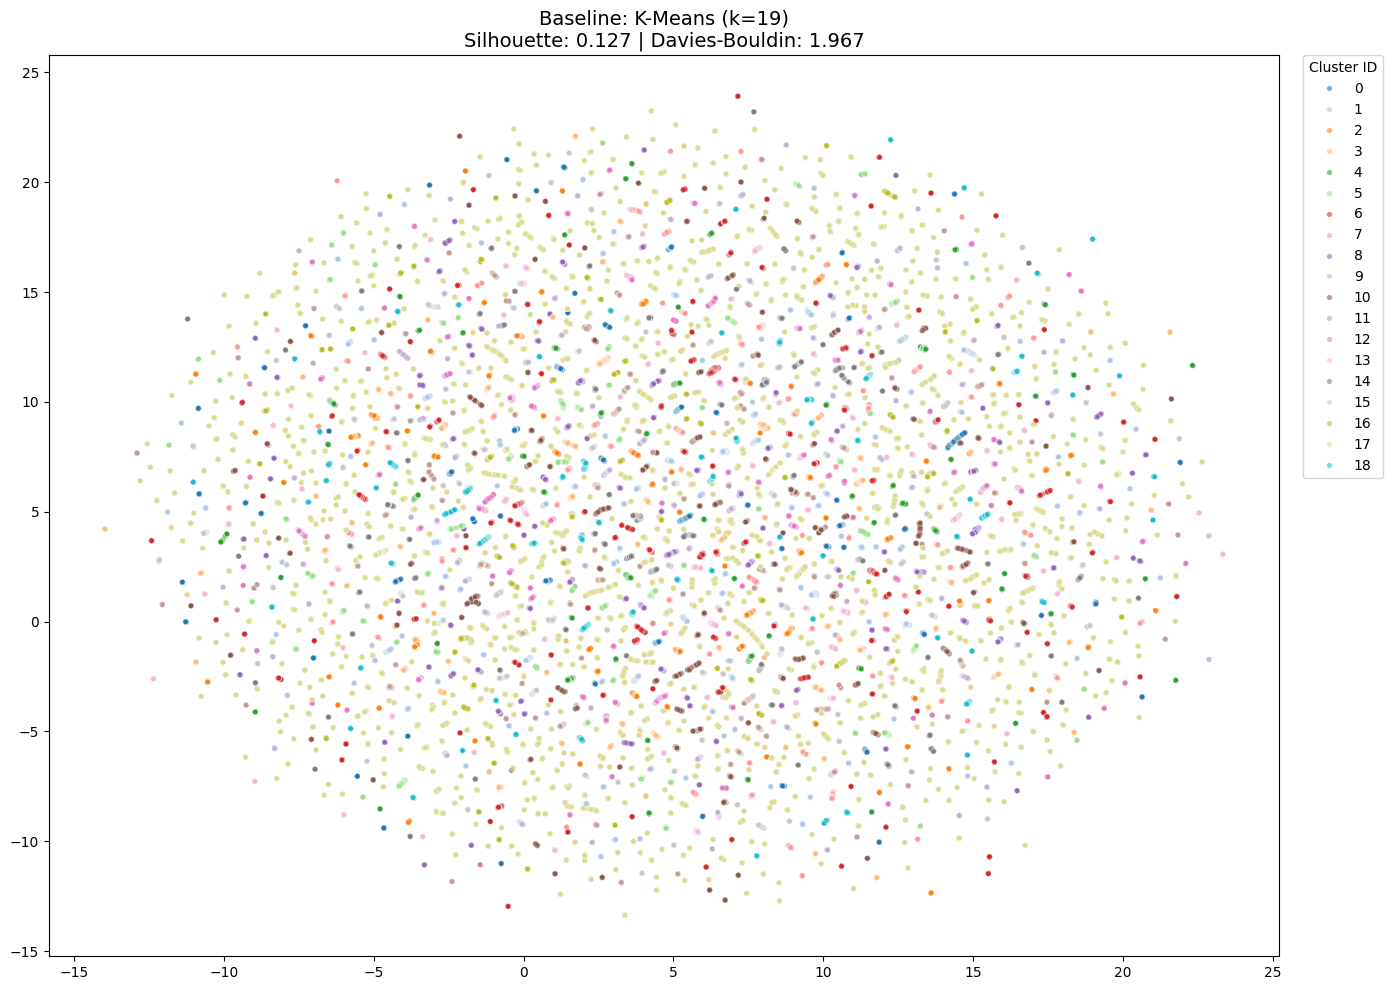

In [4]:
import warnings
from sklearn.metrics import davies_bouldin_score
import seaborn as sns

warnings.filterwarnings('ignore', message='.*n_jobs value.*')

CHOSEN_K = 19  
print("="*80)
print(f">>> TRENOWANIE K-MEANS (K={CHOSEN_K}) <<<")
print("="*80)

kmeans = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_train_umap)

print("\n[*] ROZKŁAD KLASTRÓW:")
cluster_counts = pd.Series(labels_kmeans).value_counts().sort_index()
print(cluster_counts)
print("-" * 30)

# Metryki
db_score = davies_bouldin_score(X_train_umap, labels_kmeans)
print(f"[+] Davies-Bouldin Index: {db_score:.4f} (Im mniej, tym lepiej)")

# Zawsze używamy próbki dla przyspieszenia Silhouette
idx = np.random.choice(len(X_train_umap), min(10000, len(X_train_umap)), replace=False)
sil_km = silhouette_score(X_train_umap[idx], labels_kmeans[idx])
print(f"[+] Silhouette Score:     {sil_km:.4f} (Na próbce 10k)")

# Wizualizacja
print("\n[*] Generowanie rzutu 2D dla wizualizacji...")
if X_train_umap.shape[1] > 2:
    reducer_viz = umap.UMAP(n_components=2, random_state=42, init='random')
    embedding = reducer_viz.fit_transform(X_train_umap)
else:
    embedding = X_train_umap

plt.figure(figsize=(14, 10))
sns.scatterplot(
    x=embedding[:, 0], y=embedding[:, 1],
    hue=labels_kmeans, palette='tab20',      
    s=15, alpha=0.6, legend='full'
)

plt.title(f"Baseline: K-Means (k={CHOSEN_K})\nSilhouette: {sil_km:.3f} | Davies-Bouldin: {db_score:.3f}", fontsize=14)
plt.legend(bbox_to_anchor=(1.02, 1), loc=2, borderaxespad=0., title="Cluster ID")
plt.tight_layout()

output_dir = '../wykresy'
if not os.path.exists(output_dir): os.makedirs(output_dir)
filename = os.path.join(output_dir, 'kmeans_baseline_clusters.png')
plt.savefig(filename, dpi=300, bbox_inches='tight')
print(f"[SUKCES] Wykres zapisany jako: {filename}")
plt.show()